# Day 2 Regression Practice with PyTorch

## 주제: Diabetes 데이터셋으로 회귀 모델 만들기

이번 실습에서는 scikit-learn에 내장된 `load_diabetes()` 데이터셋을 사용합니다.

---

## 오늘 배울 내용

1. 회귀 문제와 분류 문제의 차이 이해하기
2. scikit-learn 내장 데이터셋 불러오기
3. 데이터를 train/test로 나누기
4. PyTorch로 간단한 회귀 모델 만들기
5. MSE Loss로 학습하기
6. 예측값과 실제값 비교하기

---

## 회귀 문제란?

회귀는 정해진 클래스 중 하나를 고르는 문제가 아니라, **연속적인 숫자 값**을 예측하는 문제입니다.

예시:

- 집값 예측
- 온도 예측
- 매출 예측
- 환자 상태 수치 예측

이번 실습에서는 여러 건강 지표를 이용해 **당뇨병 진행 정도를 나타내는 수치**를 예측합니다.

In [1]:
# 필요한 라이브러리 불러오기

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# 실행 결과를 재현하기 위한 seed 고정
np.random.seed(42)
torch.manual_seed(42)

print("PyTorch version:", torch.__version__)

PyTorch version: 2.10.0+cpu


## 1. 데이터셋 불러오기

`load_diabetes()`는 scikit-learn에 포함된 작은 회귀용 데이터셋입니다.

Colab에서 별도 파일 업로드 없이 바로 사용할 수 있습니다.

In [2]:
diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Feature names:")
print(diabetes.feature_names)

X shape: (442, 10)
y shape: (442,)
Feature names:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


## 2. 데이터프레임으로 확인하기



In [3]:
df = pd.DataFrame(X, columns=diabetes.feature_names)
df["target"] = y

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [4]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


## 3. 입력 X와 정답 y 이해하기

이번 실습에서 모델이 하는 일은 다음과 같습니다.

- 입력 `X`: 환자의 여러 건강 관련 수치 10개
- 정답 `y`: 당뇨병 진행 정도를 나타내는 연속값
- 목표: X를 보고 y를 예측하는 회귀 모델 만들기

즉, 모델은 다음과 같은 함수를 학습합니다.

```text
건강 지표 10개 → 당뇨병 진행 정도 예측값
```

## 4. Train/Test 데이터 나누기

모델을 학습할 데이터와 평가할 데이터를 나눕니다.

- Train data: 모델이 공부하는 데이터
- Test data: 모델이 처음 보는 문제

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (353, 10)
X_test: (89, 10)
y_train: (353,)
y_test: (89,)


## 5. 데이터 정규화

입력 feature들의 범위가 다르면 모델이 학습하기 어려울 수 있습니다.

그래서 `StandardScaler`를 사용해 평균 0, 표준편차 1에 가깝게 변환합니다.

주의: scaler는 train 데이터에만 `fit`하고, test 데이터에는 `transform`만 적용합니다.

In [6]:
scaler_X = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

print("Before scaling")
print(X_train[:3])

print("\nAfter scaling")
print(X_train_scaled[:3])

Before scaling
[[ 0.07076875  0.05068012  0.01211685  0.0563009   0.03420581  0.04941617
  -0.03971921  0.03430886  0.02736405 -0.0010777 ]
 [-0.00914709  0.05068012 -0.01806189 -0.03321323 -0.0208323   0.01215151
  -0.07285395  0.07120998  0.00027248  0.01963284]
 [ 0.00538306 -0.04464164  0.04984027  0.09761511 -0.01532849 -0.016345
  -0.00658447 -0.00259226  0.01703607 -0.01350402]]

After scaling
[[ 1.49836523  1.06136988  0.21990201  1.13887373  0.72847289  1.05589332
  -0.82445065  0.71103773  0.54748197 -0.06144896]
 [-0.22885822  1.06136988 -0.41936607 -0.71059105 -0.4249289   0.27242452
  -1.52979055  1.4842858  -0.01975653  0.36723647]
 [ 0.08518241 -0.94217861  1.01898711  1.99247286 -0.30958872 -0.32669867
  -0.11911075 -0.06221033  0.3312366  -0.31866022]]


## 6. NumPy 배열을 PyTorch Tensor로 변환하기

PyTorch 모델은 `torch.Tensor` 형태의 데이터를 사용합니다.

회귀 문제의 정답 `y`는 shape을 `[데이터 개수, 1]` 형태로 만들어줍니다.

In [7]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

print("X_train_tensor:", X_train_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)

X_train_tensor: torch.Size([353, 10])
y_train_tensor: torch.Size([353, 1])


## 7. DataLoader 만들기

`DataLoader`는 데이터를 mini-batch 단위로 나누어 모델에 넣어줍니다.

batch size가 32라는 것은 한 번에 32개씩 데이터를 보고 학습한다는 뜻입니다.

In [8]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

for batch_X, batch_y in train_loader:
    print("batch_X shape:", batch_X.shape)
    print("batch_y shape:", batch_y.shape)
    break

batch_X shape: torch.Size([32, 10])
batch_y shape: torch.Size([32, 1])


## 8. PyTorch 회귀 모델 만들기

아래 모델은 아주 간단한 인공신경망입니다.

입력 feature는 10개이고, 최종 출력은 예측값 1개입니다.

```text
10개 입력 → 64개 hidden unit → 32개 hidden unit → 1개 출력
```

In [9]:
class RegressionModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

input_dim = X_train_tensor.shape[1]
model = RegressionModel(input_dim)

print(model)

RegressionModel(
  (model): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 9. Loss Function과 Optimizer 설정하기

회귀 문제에서는 보통 MSE Loss를 많이 사용합니다.

MSE는 예측값과 실제값의 차이를 제곱해서 평균낸 값입니다.

- 예측이 정확할수록 MSE는 작아집니다.
- 예측이 틀릴수록 MSE는 커집니다.

In [10]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

## 10. 모델 학습하기

이제 모델을 학습합니다.

학습 과정은 다음 순서로 반복됩니다.

1. 예측하기
2. Loss 계산하기
3. 기울기 초기화하기
4. 역전파하기
5. 파라미터 업데이트하기

In [11]:
epochs = 100
train_losses = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0

    for batch_X, batch_y in train_loader:
        # 1. 예측
        pred = model(batch_X)

        # 2. Loss 계산
        loss = criterion(pred, batch_y)

        # 3. 기울기 초기화
        optimizer.zero_grad()

        # 4. 역전파
        loss.backward()

        # 5. 파라미터 업데이트
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

Epoch [10/100], Loss: 3228.3036
Epoch [20/100], Loss: 2528.3203
Epoch [30/100], Loss: 2605.0116
Epoch [40/100], Loss: 2766.6308
Epoch [50/100], Loss: 2368.7943
Epoch [60/100], Loss: 2594.7460
Epoch [70/100], Loss: 2468.7324
Epoch [80/100], Loss: 2654.4185
Epoch [90/100], Loss: 2778.0134
Epoch [100/100], Loss: 2307.9376


## 11. 학습 과정 시각화하기

Loss가 점점 줄어드는지 확인합니다.

Loss가 줄어든다는 것은 모델이 학습 데이터를 더 잘 맞추고 있다는 뜻입니다.

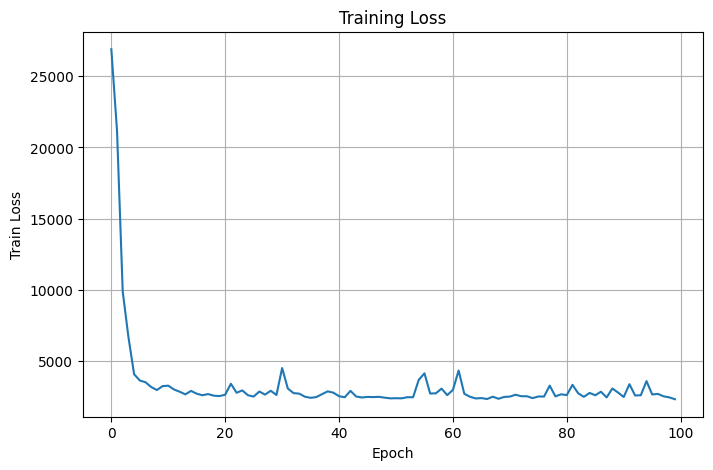

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

## 12. Test 데이터로 평가하기

이제 모델이 학습 때 보지 못했던 test 데이터에 대해 얼마나 잘 예측하는지 확인합니다.

평가 지표:

- MSE: 평균 제곱 오차
- MAE: 평균 절대 오차
- R² Score: 모델 설명력. 1에 가까울수록 좋습니다.

In [13]:
model.eval()

with torch.no_grad():
    y_pred_tensor = model(X_test_tensor)

y_pred = y_pred_tensor.numpy().flatten()

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R² Score: {r2:.4f}")

MSE: 2695.34
MAE: 41.22
R² Score: 0.4913


## 13. 실제값과 예측값 비교하기

실제값과 예측값이 비슷하다면 좋은 모델입니다.

완벽하게 일치하지 않아도 됩니다. 중요한 것은 전체적인 경향을 잘 따라가는지입니다.

In [14]:
result_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

result_df.head(10)

,Actual,Predicted
0,219.0,159.485535
1,70.0,190.771194
2,202.0,162.562134
3,230.0,304.764801
4,111.0,95.895187
5,84.0,112.925697
6,242.0,298.372833
7,272.0,194.418304
8,94.0,79.744072
9,96.0,83.088814


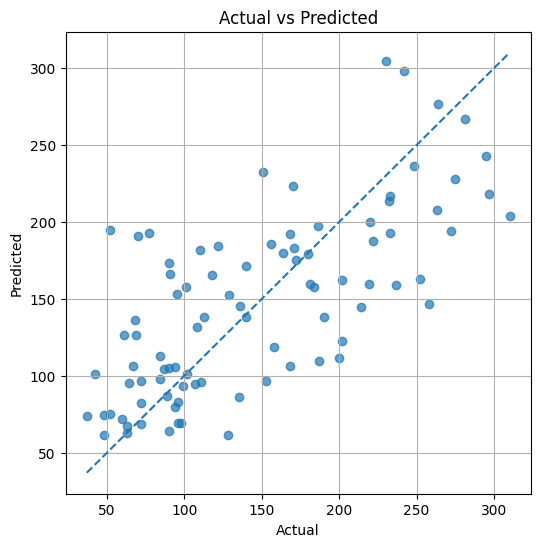

In [15]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.grid(True)
plt.show()

## 14. 예측 결과 일부 확인하기

모델이 예측한 값과 실제 정답을 몇 개만 직접 비교해봅니다.

In [16]:
for i in range(10):
    print(f"Sample {i+1}: Actual = {y_test[i]:.1f}, Predicted = {y_pred[i]:.1f}")

Sample 1: Actual = 219.0, Predicted = 159.5
Sample 2: Actual = 70.0, Predicted = 190.8
Sample 3: Actual = 202.0, Predicted = 162.6
Sample 4: Actual = 230.0, Predicted = 304.8
Sample 5: Actual = 111.0, Predicted = 95.9
Sample 6: Actual = 84.0, Predicted = 112.9
Sample 7: Actual = 242.0, Predicted = 298.4
Sample 8: Actual = 272.0, Predicted = 194.4
Sample 9: Actual = 94.0, Predicted = 79.7
Sample 10: Actual = 96.0, Predicted = 83.1


## 15. 직접 실험해보기

아래 항목을 바꾸면서 결과가 어떻게 달라지는지 확인해보세요.

### 실험 1
`epochs = 100`을 `50`, `200`, `500`으로 바꿔보세요.

### 실험 2
Learning rate `lr=0.01`을 `0.001`, `0.1`로 바꿔보세요.

### 실험 3
모델 구조를 바꿔보세요.

예시:

```python
nn.Linear(input_dim, 128)
nn.ReLU()
nn.Linear(128, 64)
nn.ReLU()
nn.Linear(64, 1)
```

### 실험 4
Batch size를 `16`, `32`, `64`로 바꿔보세요.



## 마무리

이번 실습에서는 Colab에서 바로 사용할 수 있는 `load_diabetes()` 데이터셋으로 PyTorch 회귀 모델을 만들었습니다.

핵심 흐름은 다음과 같습니다.

```text
데이터 불러오기
→ train/test 분리
→ 정규화
→ Tensor 변환
→ 모델 정의
→ 학습
→ 평가
→ 결과 시각화
```

이 흐름은 집값 예측, 매출 예측, 온도 예측 등 다른 회귀 문제에도 거의 그대로 사용할 수 있습니다.